In [1]:
from pathlib import Path
import json
import time
import random
import inspect

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import Dataset, DataLoader

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

current_directory = Path.cwd().resolve()
if (current_directory / 'final-2' / 'output').exists():
    project_folder = current_directory / 'final-2'
elif current_directory.name == 'notebooks' and (current_directory.parent / 'output').exists():
    project_folder = current_directory.parent
else:
    project_folder = current_directory

dataset_path = project_folder / 'output' / 'particle_ugradu_dataset.npz'
training_results_folder = project_folder / 'output' / 'task1_v3_simple_training'
results_folder = project_folder / 'output' / 'task1_v3_analysis'
results_folder.mkdir(parents=True, exist_ok=True)
checkpoint_path = training_results_folder / 'best_task1_v3_model.pt'
history_path = training_results_folder / 'history.json'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Project folder          :', project_folder)
print('Dataset path            :', dataset_path)
print('Checkpoint path         :', checkpoint_path)
print('Analysis results folder :', results_folder)
print('Device                  :', device)
if device.type == 'cuda':
    print('GPU                     :', torch.cuda.get_device_name(0))

if not dataset_path.exists():
    raise FileNotFoundError('Missing particle_ugradu_dataset.npz. Run final-2/preprocess_data.py first.')
if not checkpoint_path.exists():
    raise FileNotFoundError('Missing best_task1_v3_model.pt. Run task1_v3_model.ipynb training first.')



Project folder          : C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\final-2
Dataset path            : C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\final-2\output\particle_ugradu_dataset.npz
Checkpoint path         : C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\final-2\output\task1_v3_simple_training\best_task1_v3_model.pt
Analysis results folder : C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\final-2\output\task1_v3_analysis
Device                  : cuda
GPU                     : NVIDIA RTX 4000 Ada Generation


In [3]:
# Load checkpoint first, because its feature list defines the exact input channels used by the saved model.
# This is important when the model notebook changes input-channel toggles after an older checkpoint was trained.
try:
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
except TypeError:
    checkpoint = torch.load(checkpoint_path, map_location=device)

checkpoint_feature_names = [str(name) for name in checkpoint.get('feature_names', [])]
checkpoint_target_names = [str(name) for name in checkpoint.get('target_names', [])]
model_config = dict(checkpoint.get('model_config', {}))
settings = dict(checkpoint.get('settings', {}))
loss_name = str(checkpoint.get('loss_name', 'unknown'))

if len(checkpoint_feature_names) == 0:
    raise RuntimeError('Checkpoint does not contain feature_names. Cannot safely reconstruct model inputs.')
if len(checkpoint_target_names) == 0:
    raise RuntimeError('Checkpoint does not contain target_names. Cannot safely reconstruct targets.')

print('Checkpoint best epoch     :', checkpoint.get('best_epoch', 'unknown'))
print('Checkpoint best metric    :', checkpoint.get('best_checkpoint_metric', 'unknown'))
print('Checkpoint loss           :', loss_name)
print('Checkpoint model config   :', model_config)
print('Checkpoint input features :', checkpoint_feature_names)
print('Checkpoint targets        :', checkpoint_target_names)

# Load optional training history saved by the model notebook. Older runs may not have this file.
if history_path.exists():
    history = json.loads(history_path.read_text())
    print('Loaded training history rows:', len(history))
else:
    history = []
    print('[info] No history.json found. Learning-curve plots will be skipped, but checkpoint evaluation still works.')



Checkpoint best epoch     : 56
Checkpoint best metric    : 0.13854369707405567
Checkpoint loss           : smooth_l1
Checkpoint model config   : {'hidden_size': 128, 'graph_layers': 3, 'neighbor_radius': 0.12, 'dropout': 0.06}
Checkpoint input features : ['x', 'y', 'z', 'Gamma_x', 'Gamma_y', 'Gamma_z', 'sigma', 'geom_dist', 'geom_nx', 'geom_ny', 'geom_nz', 'angle_of_attack', 'phase']
Checkpoint targets        : ['velocity_x', 'velocity_y', 'velocity_z', 'gradUx_x', 'gradUx_y', 'gradUx_z', 'gradUy_x', 'gradUy_y', 'gradUy_z', 'gradUz_x', 'gradUz_y', 'gradUz_z']
[info] No history.json found. Learning-curve plots will be skipped, but checkpoint evaluation still works.


In [4]:
# Load dataset arrays and slice them to the checkpoint feature order.
# The raw .npz may contain more channels than the checkpoint used.
dataset_file = np.load(dataset_path, allow_pickle=True)
raw_feature_names_from_file = [str(name) for name in dataset_file['feature_names'].tolist()]
target_names_from_file = [str(name) for name in dataset_file['target_names'].tolist()]
frame_contexts = list(dataset_file['frame_contexts'])
frame_ranges = list(dataset_file['frame_ranges'])

missing_features = [name for name in checkpoint_feature_names if name not in raw_feature_names_from_file]
if missing_features:
    raise RuntimeError(f'Checkpoint expects features missing from dataset: {missing_features}')
missing_targets = [name for name in checkpoint_target_names if name not in target_names_from_file]
if missing_targets:
    raise RuntimeError(f'Checkpoint expects targets missing from dataset: {missing_targets}')

active_input_feature_indices = [raw_feature_names_from_file.index(name) for name in checkpoint_feature_names]
target_indices = [target_names_from_file.index(name) for name in checkpoint_target_names]
feature_names = list(checkpoint_feature_names)
target_names = list(checkpoint_target_names)

if 'inputs_by_frame_norm' not in dataset_file or 'targets_by_frame_norm' not in dataset_file:
    raise RuntimeError('This notebook expects frame-wise arrays from preprocess_data.py.')

inputs_by_frame_normalized = [
    np.asarray(x, dtype=np.float32)[:, active_input_feature_indices]
    for x in dataset_file['inputs_by_frame_norm'].tolist()
]
targets_by_frame_normalized = [
    np.asarray(y, dtype=np.float32)[:, target_indices]
    for y in dataset_file['targets_by_frame_norm'].tolist()
]
inputs_by_frame_raw = [
    np.asarray(x, dtype=np.float32)[:, active_input_feature_indices]
    for x in dataset_file['inputs_by_frame'].tolist()
]
targets_by_frame_raw = [
    np.asarray(y, dtype=np.float32)[:, target_indices]
    for y in dataset_file['targets_by_frame'].tolist()
]

input_mean = dataset_file['in_mean'].astype(np.float32).reshape(-1)[active_input_feature_indices]
input_standard_deviation = dataset_file['in_std'].astype(np.float32).reshape(-1)[active_input_feature_indices]
target_mean_np = dataset_file['out_mean'].astype(np.float32).reshape(-1)[target_indices]
target_standard_deviation_np = dataset_file['out_std'].astype(np.float32).reshape(-1)[target_indices]
output_mean = torch.tensor(target_mean_np, dtype=torch.float32, device=device)
output_standard_deviation = torch.tensor(target_standard_deviation_np, dtype=torch.float32, device=device)

training_frame_ids = dataset_file['train_frame_ids'].astype(np.int64)
validation_frame_ids = dataset_file['val_id_frame_ids'].astype(np.int64) if 'val_id_frame_ids' in dataset_file.files else np.array([], dtype=np.int64)
validation_angle_frame_ids = dataset_file['validation_angle_frame_ids'].astype(np.int64) if 'validation_angle_frame_ids' in dataset_file.files else dataset_file['val_frame_ids'].astype(np.int64) if 'val_frame_ids' in dataset_file.files else np.array([], dtype=np.int64)
testing_frame_ids = dataset_file['test_frame_ids'].astype(np.int64) if 'test_frame_ids' in dataset_file.files else np.array([], dtype=np.int64)


def frame_context_as_dict(frame_id):
    context = frame_contexts[int(frame_id)]
    if isinstance(context, dict):
        return context
    if hasattr(context, 'item'):
        maybe_dict = context.item()
        if isinstance(maybe_dict, dict):
            return maybe_dict
    return dict(context)


def make_same_distribution_validation_split(train_ids, stride=5, offset=2, min_per_case=8):
    by_case = {}
    for frame_id in np.asarray(train_ids, dtype=np.int64):
        case = str(frame_context_as_dict(int(frame_id)).get('case', frame_ranges[int(frame_id)][0]))
        by_case.setdefault(case, []).append(int(frame_id))

    train_out = []
    validation_out = []
    for case, ids in sorted(by_case.items()):
        ids_sorted = sorted(ids, key=lambda j: int(float(frame_context_as_dict(int(j)).get('frame', frame_ranges[int(j)][1]))))
        if len(ids_sorted) <= 1:
            train_out.extend(ids_sorted)
            continue
        stride_value = max(int(stride), 2)
        offset_value = min(max(int(offset), 0), stride_value - 1)
        validation_ids = ids_sorted[offset_value::stride_value]
        minimum_validation = min(max(int(min_per_case), 1), max(len(ids_sorted) - 1, 1))
        if len(validation_ids) < minimum_validation:
            existing = set(validation_ids)
            validation_ids.extend([j for j in ids_sorted if j not in existing][:minimum_validation - len(validation_ids)])
        validation_set = set(validation_ids)
        train_out.extend([j for j in ids_sorted if j not in validation_set])
        validation_out.extend(validation_ids)
    return np.asarray(sorted(train_out), dtype=np.int64), np.asarray(sorted(validation_out), dtype=np.int64)

if len(validation_frame_ids) == 0:
    print('[warn] val_id_frame_ids missing/empty; rebuilding same-distribution validation split in memory.')
    training_frame_ids, validation_frame_ids = make_same_distribution_validation_split(training_frame_ids)


def sample_frame_ids(frame_ids, maximum_frames=None, seed_offset=0, sort_after_sampling=False):
    frame_ids = np.asarray(frame_ids, dtype=np.int64)
    if maximum_frames is None or len(frame_ids) <= int(maximum_frames):
        chosen = frame_ids.copy()
    else:
        rng = np.random.default_rng(SEED + int(seed_offset))
        chosen = rng.choice(frame_ids, size=int(maximum_frames), replace=False)
    if sort_after_sampling:
        chosen = np.asarray(sorted(chosen, key=lambda f: int(float(frame_context_as_dict(int(f)).get('frame', frame_ranges[int(f)][1])))), dtype=np.int64)
    return chosen


def sample_dataset_indices(dataset, maximum_items=None, seed_offset=0):
    indices = np.arange(len(dataset), dtype=np.int64)
    if maximum_items is None or len(indices) <= int(maximum_items):
        return indices
    rng = np.random.default_rng(SEED + int(seed_offset))
    return rng.choice(indices, size=int(maximum_items), replace=False)


def test_frame_ids_for_role(role_name, saved_key, aoa_fallback=None):
    if saved_key in dataset_file.files:
        return dataset_file[saved_key].astype(np.int64)
    selected = []
    for frame_id in testing_frame_ids:
        context = frame_context_as_dict(int(frame_id))
        if str(context.get('test_role', '')) == role_name:
            selected.append(int(frame_id))
            continue
        if aoa_fallback is not None and int(round(float(context.get('aoa_deg', -999)))) == int(aoa_fallback):
            selected.append(int(frame_id))
    return np.asarray(selected, dtype=np.int64)


def target_norm_for_frame(frame_id):
    target = targets_by_frame_raw[int(frame_id)]
    return float(np.linalg.norm(target.reshape(-1)))


def filter_zero_target_frames(frame_ids, split_name, minimum_norm=1.0e-12):
    kept = []
    removed = []
    for frame_id in np.asarray(frame_ids, dtype=np.int64):
        norm_value = target_norm_for_frame(int(frame_id))
        if norm_value > minimum_norm:
            kept.append(int(frame_id))
        else:
            context = frame_context_as_dict(int(frame_id))
            removed.append((int(frame_id), context.get('case', 'unknown'), context.get('frame', 'unknown')))
    if removed:
        print(f'[filter] {split_name}: removed {len(removed)} zero-target frames; examples={removed[:3]}')
    return np.asarray(kept, dtype=np.int64)


testing_normal_frame_ids = test_frame_ids_for_role('testing_normal', 'test_normal_frame_ids', aoa_fallback=27)
testing_super_resolution_frame_ids = test_frame_ids_for_role('testing_super_resolution', 'test_super_resolution_frame_ids', aoa_fallback=19)
testing_unseen_angle_frame_ids = test_frame_ids_for_role('testing_unseen_angle', 'test_unseen_angle_frame_ids', aoa_fallback=32)

training_frame_ids = filter_zero_target_frames(training_frame_ids, 'training')
validation_frame_ids = filter_zero_target_frames(validation_frame_ids, 'validation')
validation_angle_frame_ids = filter_zero_target_frames(validation_angle_frame_ids, 'validation_angle')
testing_frame_ids = filter_zero_target_frames(testing_frame_ids, 'testing_all')
testing_normal_frame_ids = filter_zero_target_frames(testing_normal_frame_ids, 'testing_normal')
testing_super_resolution_frame_ids = filter_zero_target_frames(testing_super_resolution_frame_ids, 'testing_super_resolution')
testing_unseen_angle_frame_ids = filter_zero_target_frames(testing_unseen_angle_frame_ids, 'testing_unseen_angle')

input_dimension = int(inputs_by_frame_normalized[0].shape[1])
output_dimension = int(targets_by_frame_normalized[0].shape[1])
print('Input features used by checkpoint:', feature_names)
print('Target names:', target_names)
print('Frames: train/val/test =', len(training_frame_ids), len(validation_frame_ids), len(testing_frame_ids))



[warn] val_id_frame_ids missing/empty; rebuilding same-distribution validation split in memory.
[filter] training: removed 11 zero-target frames; examples=[(0, '10deg_static_airfoil_10u_1p', '000000'), (402, '12deg_static_airfoil_10u_1p', '000000'), (603, '14deg_static_airfoil_10u_1p', '000000')]
[filter] validation_angle: removed 4 zero-target frames; examples=[(201, '11deg_static_airfoil_10u_1p', '000000'), (804, '15deg_static_airfoil_10u_1p', '000000'), (1809, '21deg_static_airfoil_10u_1p', '000000')]
[filter] testing_all: removed 3 zero-target frames; examples=[(1407, '19deg_static_airfoil_10u_2p', '000000'), (2814, '27deg_static_airfoil_10u_1p', '000000'), (3417, '32deg_static_airfoil_10u_1p', '000000')]
[filter] testing_normal: removed 1 zero-target frames; examples=[(2814, '27deg_static_airfoil_10u_1p', '000000')]
[filter] testing_super_resolution: removed 1 zero-target frames; examples=[(1407, '19deg_static_airfoil_10u_2p', '000000')]
[filter] testing_unseen_angle: removed 1 ze

In [5]:
# Dataset wrappers and helper functions used by analysis/evaluation.

class ParticleFrameDataset(Dataset):
    def __init__(self, frame_ids):
        self.frame_ids = [int(frame_id) for frame_id in frame_ids]

    def __len__(self):
        return len(self.frame_ids)

    def __getitem__(self, index):
        frame_id = self.frame_ids[index]
        input_normalized = torch.from_numpy(inputs_by_frame_normalized[frame_id])
        target_normalized = torch.from_numpy(targets_by_frame_normalized[frame_id])
        input_raw = torch.from_numpy(inputs_by_frame_raw[frame_id])
        context = frame_context_as_dict(frame_id)
        metadata = {
            'frame_id': frame_id,
            'case': str(context.get('case', 'unknown')),
            'frame': str(context.get('frame', context.get('fr', 'unknown'))),
            'particle_count': int(context.get('n_particles', input_normalized.shape[0])),
        }
        return input_normalized, target_normalized, input_raw, metadata


def collate_one_frame(batch):
    inputs, targets, raw_inputs, metadata = zip(*batch)
    return list(inputs), list(targets), list(raw_inputs), list(metadata)

training_dataset = ParticleFrameDataset(training_frame_ids)
validation_dataset = ParticleFrameDataset(validation_frame_ids)
testing_dataset = ParticleFrameDataset(testing_frame_ids)
testing_normal_dataset = ParticleFrameDataset(testing_normal_frame_ids)
testing_super_resolution_dataset = ParticleFrameDataset(testing_super_resolution_frame_ids)
testing_unseen_angle_dataset = ParticleFrameDataset(testing_unseen_angle_frame_ids)

training_loader = DataLoader(training_dataset, batch_size=1, shuffle=False, collate_fn=collate_one_frame)
validation_loader = DataLoader(validation_dataset, batch_size=1, shuffle=False, collate_fn=collate_one_frame)
testing_loader = DataLoader(testing_dataset, batch_size=1, shuffle=False, collate_fn=collate_one_frame)
testing_normal_loader = DataLoader(testing_normal_dataset, batch_size=1, shuffle=False, collate_fn=collate_one_frame)
testing_super_resolution_loader = DataLoader(testing_super_resolution_dataset, batch_size=1, shuffle=False, collate_fn=collate_one_frame)
testing_unseen_angle_loader = DataLoader(testing_unseen_angle_dataset, batch_size=1, shuffle=False, collate_fn=collate_one_frame)

# Use checkpoint settings if present; otherwise safe analysis defaults.
settings.setdefault('particles_per_frame_final', 2048)
settings.setdefault('maximum_particles_before_gpu', 6000)
settings.setdefault('validation_frames_per_check', 20)


def denormalize_target(target_normalized):
    return target_normalized * output_standard_deviation + output_mean


def subsample_before_gpu(input_tensor, target_tensor, raw_input_tensor, maximum_particles):
    particle_count = input_tensor.shape[0]
    if particle_count <= maximum_particles:
        return input_tensor, target_tensor, raw_input_tensor
    picked = torch.randperm(particle_count)[:maximum_particles]
    return input_tensor[picked], target_tensor[picked], raw_input_tensor[picked]


def subsample_for_training(input_tensor, target_tensor, raw_input_tensor, particle_cap):
    particle_count = input_tensor.shape[0]
    if particle_count <= particle_cap:
        return input_tensor, target_tensor, raw_input_tensor
    picked = torch.randperm(particle_count, device=input_tensor.device)[:particle_cap]
    return input_tensor[picked], target_tensor[picked], raw_input_tensor[picked]


def finite_mean(values):
    finite = [float(v) for v in values if np.isfinite(v)]
    return float(np.mean(finite)) if finite else np.nan

minimum_target_norm_for_relative_error = 1e-6


def component_metrics(prediction, target):
    difference = prediction - target
    target_norm = torch.linalg.norm(target.reshape(-1))
    difference_norm = torch.linalg.norm(difference.reshape(-1))
    relative_error = np.nan if target_norm.item() <= minimum_target_norm_for_relative_error else (difference_norm / target_norm).item()
    rmse = torch.sqrt(torch.mean(difference ** 2)).item()
    mae = torch.mean(torch.abs(difference)).item()
    target_rms = torch.sqrt(torch.mean(target ** 2)).item()
    return relative_error, rmse, mae, target_norm.item(), target_rms


def physical_metrics(prediction_normalized, target_normalized):
    prediction = denormalize_target(prediction_normalized)
    target = denormalize_target(target_normalized)
    full_rel, full_rmse, full_mae, full_target_norm, full_target_rms = component_metrics(prediction, target)
    velocity_rel, velocity_rmse, velocity_mae, velocity_target_norm, velocity_target_rms = component_metrics(prediction[:, :3], target[:, :3])
    gradient_rel, gradient_rmse, gradient_mae, gradient_target_norm, gradient_target_rms = component_metrics(prediction[:, 3:], target[:, 3:])
    return {
        'relative_error': full_rel,
        'rmse': full_rmse,
        'mae': full_mae,
        'target_norm': full_target_norm,
        'target_rms': full_target_rms,
        'velocity_relative_error': velocity_rel,
        'velocity_rmse': velocity_rmse,
        'velocity_mae': velocity_mae,
        'velocity_target_norm': velocity_target_norm,
        'velocity_target_rms': velocity_target_rms,
        'velocity_gradient_relative_error': gradient_rel,
        'velocity_gradient_rmse': gradient_rmse,
        'velocity_gradient_mae': gradient_mae,
        'velocity_gradient_target_norm': gradient_target_norm,
        'velocity_gradient_target_rms': gradient_target_rms,
    }

@torch.no_grad()
def evaluate_model(data_loader, maximum_frames, particle_cap):
    if len(data_loader.dataset) == 0:
        return {'relative_error': np.nan, 'rmse': np.nan, 'mae': np.nan, 'velocity_relative_error': np.nan, 'velocity_rmse': np.nan, 'velocity_gradient_relative_error': np.nan, 'velocity_gradient_rmse': np.nan, 'frames_evaluated': 0, 'frames_skipped_for_relative_error': 0}
    model.eval()
    collected = []
    skipped_for_relative = 0
    sampled_indices = sample_dataset_indices(data_loader.dataset, maximum_frames, seed_offset=67)
    for dataset_index in sampled_indices:
        input_tensor, target_tensor, raw_input_tensor, metadata = data_loader.dataset[int(dataset_index)]
        input_tensor, target_tensor, raw_input_tensor = subsample_before_gpu(input_tensor, target_tensor, raw_input_tensor, settings['maximum_particles_before_gpu'])
        input_tensor, target_tensor, raw_input_tensor = subsample_for_training(input_tensor.to(device), target_tensor.to(device), raw_input_tensor.to(device), particle_cap)
        prediction = model(input_tensor).float()
        metrics = physical_metrics(prediction, target_tensor.float())
        if not np.isfinite(metrics['relative_error']):
            skipped_for_relative += 1
        collected.append(metrics)
    return {
        'relative_error': finite_mean([m['relative_error'] for m in collected]),
        'rmse': finite_mean([m['rmse'] for m in collected]),
        'mae': finite_mean([m['mae'] for m in collected]),
        'velocity_relative_error': finite_mean([m['velocity_relative_error'] for m in collected]),
        'velocity_rmse': finite_mean([m['velocity_rmse'] for m in collected]),
        'velocity_gradient_relative_error': finite_mean([m['velocity_gradient_relative_error'] for m in collected]),
        'velocity_gradient_rmse': finite_mean([m['velocity_gradient_rmse'] for m in collected]),
        'frames_evaluated': int(len(collected)),
        'frames_skipped_for_relative_error': int(skipped_for_relative),
    }



In [6]:
# Reconstruct the model architecture from checkpoint state-dict keys, then load saved weights.
# This supports both older GNOBlock checkpoints and newer edge-feature-message checkpoints.

state_dict = checkpoint['model_state_dict']
state_keys = list(state_dict.keys())
uses_legacy_gnoblock = any('.integral_transform.' in key for key in state_keys)
uses_edge_feature_block = any('.message_network.' in key for key in state_keys)


def relative_l2_error(prediction, target, small_number=1e-12):
    difference = (prediction - target).reshape(prediction.shape[0], -1)
    reference = target.reshape(target.shape[0], -1)
    return (torch.linalg.norm(difference, dim=1) / torch.linalg.norm(reference, dim=1).clamp_min(small_number)).mean()


if uses_legacy_gnoblock:
    from neuralop.layers.gno_block import GNOBlock

    class LegacyParticleVelocityGradientModel(nn.Module):
        def __init__(self, input_size, output_size, hidden_size=96, graph_layers=2, neighbor_radius=0.12, dropout=0.04):
            super().__init__()
            self.neighbor_radius = float(neighbor_radius)
            self.input_network = nn.Sequential(
                nn.Linear(input_size, hidden_size),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_size, hidden_size),
                nn.GELU(),
                nn.Linear(hidden_size, hidden_size),
            )

            block_arguments = {}
            signature = inspect.signature(GNOBlock.__init__)
            if 'use_torch_scatter_reduce' in signature.parameters:
                try:
                    import torch_scatter  # noqa: F401
                    block_arguments['use_torch_scatter_reduce'] = True
                except Exception:
                    block_arguments['use_torch_scatter_reduce'] = False
            if 'use_open3d_neighbor_search' in signature.parameters:
                try:
                    import open3d  # noqa: F401
                    block_arguments['use_open3d_neighbor_search'] = True
                except Exception:
                    block_arguments['use_open3d_neighbor_search'] = False

            self.graph_blocks = nn.ModuleList([
                GNOBlock(
                    in_channels=hidden_size,
                    out_channels=hidden_size,
                    coord_dim=3,
                    radius=self.neighbor_radius,
                    transform_type='linear',
                    reduction='mean',
                    pos_embedding_type='transformer',
                    pos_embedding_channels=16,
                    channel_mlp_layers=[hidden_size, hidden_size, hidden_size],
                    **block_arguments,
                )
                for _ in range(graph_layers)
            ])
            self.normalization_layers = nn.ModuleList([nn.LayerNorm(hidden_size) for _ in range(graph_layers)])
            self.output_network = nn.Sequential(
                nn.Linear(hidden_size, hidden_size),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_size, output_size),
            )
            self.backend_information = {'checkpoint_architecture': 'legacy_gnoblock', **block_arguments}

        def forward(self, particle_features):
            particle_positions = particle_features[:, :3]
            hidden = self.input_network(particle_features)
            neighbor_cache = None
            for graph_block, normalization_layer in zip(self.graph_blocks, self.normalization_layers):
                if neighbor_cache is None:
                    neighbor_cache = graph_block.neighbor_search(
                        data=particle_positions,
                        queries=particle_positions,
                        radius=self.neighbor_radius,
                    )
                embedded_positions = graph_block.pos_embedding(particle_positions) if graph_block.pos_embedding is not None else particle_positions
                update = graph_block.integral_transform(
                    y=embedded_positions,
                    x=embedded_positions,
                    neighbors=neighbor_cache,
                    f_y=hidden,
                )
                if update.ndim == 3 and update.shape[0] == 1:
                    update = update.squeeze(0)
                hidden = normalization_layer(hidden + update)
            return self.output_network(hidden)

    model = LegacyParticleVelocityGradientModel(
        input_size=input_dimension,
        output_size=output_dimension,
        **model_config,
    ).to(device)

else:
    from neuralop.layers.neighbor_search import NeighborSearch

    class EdgeFeatureMessageBlock(nn.Module):
        def __init__(self, hidden_size, neighbor_radius, use_open3d_neighbor_search=True, dropout=0.04):
            super().__init__()
            self.neighbor_radius = float(neighbor_radius)
            self.neighbor_search = NeighborSearch(use_open3d=use_open3d_neighbor_search, return_norm=False)
            edge_feature_size = 2 * hidden_size + 14
            self.message_network = nn.Sequential(
                nn.Linear(edge_feature_size, hidden_size),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_size, hidden_size),
                nn.GELU(),
                nn.Linear(hidden_size, hidden_size),
            )
            self.normalization = nn.LayerNorm(hidden_size)

        def forward(self, hidden, search_positions, physical_positions, gamma_values, sigma_values):
            neighbors = self.neighbor_search(data=search_positions, queries=search_positions, radius=self.neighbor_radius)
            source_index = neighbors['neighbors_index'].long()
            row_splits = neighbors['neighbors_row_splits'].long()
            neighbor_counts = row_splits[1:] - row_splits[:-1]
            if source_index.numel() == 0:
                return hidden
            target_index = torch.repeat_interleave(torch.arange(search_positions.shape[0], device=search_positions.device), neighbor_counts)
            relative_position = physical_positions[source_index] - physical_positions[target_index]
            distance = torch.linalg.norm(relative_position, dim=-1, keepdim=True)
            sigma_source = sigma_values[source_index].abs().clamp_min(1.0e-8)
            sigma_target = sigma_values[target_index].abs().clamp_min(1.0e-8)
            edge_features = torch.cat([
                hidden[source_index],
                hidden[target_index],
                relative_position,
                distance,
                distance / sigma_source,
                distance / sigma_target,
                gamma_values[source_index],
                gamma_values[target_index],
                sigma_source,
                sigma_target,
            ], dim=-1)
            messages = self.message_network(edge_features)
            aggregated = torch.zeros_like(hidden)
            aggregated.index_add_(0, target_index, messages)
            aggregated = aggregated / neighbor_counts.to(hidden.dtype).clamp_min(1.0).unsqueeze(-1)
            return self.normalization(hidden + aggregated)

    class ParticleVelocityGradientModel(nn.Module):
        def __init__(self, input_size, output_size, feature_names, input_mean, input_standard_deviation, hidden_size=96, graph_layers=2, neighbor_radius=0.12, dropout=0.04, use_physical_edge_features=True):
            super().__init__()
            self.neighbor_radius = float(neighbor_radius)
            self.feature_names = list(feature_names)
            self.use_physical_edge_features = bool(use_physical_edge_features)
            self.register_buffer('input_mean', torch.as_tensor(input_mean, dtype=torch.float32).reshape(1, -1))
            self.register_buffer('input_standard_deviation', torch.as_tensor(input_standard_deviation, dtype=torch.float32).reshape(1, -1))
            self.sigma_index = self.feature_names.index('sigma') if 'sigma' in self.feature_names else -1
            self.gamma_indices = [self.feature_names.index(name) for name in ['Gamma_x', 'Gamma_y', 'Gamma_z'] if name in self.feature_names]
            if len(self.gamma_indices) != 3:
                self.gamma_indices = []
            self.input_network = nn.Sequential(
                nn.Linear(input_size, hidden_size),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_size, hidden_size),
                nn.GELU(),
                nn.Linear(hidden_size, hidden_size),
            )
            try:
                import open3d  # noqa: F401
                use_open3d = True
            except Exception:
                use_open3d = False
            self.graph_blocks = nn.ModuleList([
                EdgeFeatureMessageBlock(hidden_size, self.neighbor_radius, use_open3d_neighbor_search=use_open3d, dropout=dropout)
                for _ in range(graph_layers)
            ])
            self.output_network = nn.Sequential(
                nn.Linear(hidden_size, hidden_size),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_size, output_size),
            )
            self.backend_information = {'checkpoint_architecture': 'edge_feature_message', 'neighbor_search': 'open3d' if use_open3d else 'native_torch'}

        def physical_feature_values(self, particle_features):
            if not self.use_physical_edge_features:
                return particle_features
            return particle_features * self.input_standard_deviation.to(particle_features.dtype) + self.input_mean.to(particle_features.dtype)

        def forward(self, particle_features):
            search_positions = particle_features[:, :3]
            physical_features = self.physical_feature_values(particle_features)
            physical_positions = physical_features[:, :3]
            sigma_values = physical_features[:, self.sigma_index:self.sigma_index + 1] if self.sigma_index >= 0 else torch.ones((particle_features.shape[0], 1), device=particle_features.device, dtype=particle_features.dtype)
            gamma_values = physical_features[:, self.gamma_indices] if self.gamma_indices else torch.zeros((particle_features.shape[0], 3), device=particle_features.device, dtype=particle_features.dtype)
            hidden = self.input_network(particle_features)
            for graph_block in self.graph_blocks:
                hidden = graph_block(hidden, search_positions, physical_positions, gamma_values, sigma_values)
            return self.output_network(hidden)

    model = ParticleVelocityGradientModel(
        input_size=input_dimension,
        output_size=output_dimension,
        feature_names=feature_names,
        input_mean=input_mean,
        input_standard_deviation=input_standard_deviation,
        **model_config,
    ).to(device)

try:
    model.load_state_dict(state_dict, strict=True)
except RuntimeError as error:
    raise RuntimeError(
        'Checkpoint does not match the reconstructed model. Make sure task1_v3_analysis.ipynb '
        'is using the same checkpoint produced by task1_v3_model.ipynb.'
    ) from error

model.eval()
trainable_parameter_count = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print('Loaded checkpoint:', checkpoint_path)
print('Architecture      :', model.backend_information)
print('Trainable params  :', f'{trainable_parameter_count:,}')



Loaded checkpoint: C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\final-2\output\task1_v3_simple_training\best_task1_v3_model.pt
Architecture      : {'checkpoint_architecture': 'edge_feature_message', 'neighbor_search': 'native_torch'}
Trainable params  : 256,780


In [7]:
# Learning curves from saved training history.
# If the model was trained before history.json was added, this section is skipped.

if len(history) == 0:
    print('[skip] No saved training history found. Re-run task1_v3_model.ipynb once to create history.json.')
else:
    epochs = [row['epoch'] for row in history]
    training_loss = [row['training_loss'] for row in history]
    training_relative_error = [row['training_relative_error'] for row in history]
    validation_relative_error = [row.get('validation_relative_error', np.nan) for row in history]
    testing_relative_error = [row.get('testing_relative_error', np.nan) for row in history]
    learning_rates = [row['learning_rate'] for row in history]
    particle_caps = [row['particle_cap'] for row in history]

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.6), constrained_layout=True)

    axes[0].plot(epochs, training_loss, marker='o', label='training loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Training loss')
    axes[0].set_title('Training loss')
    axes[0].grid(alpha=0.25)
    axes[0].legend(frameon=False)

    axes[1].plot(epochs, training_relative_error, marker='o', label='training')
    axes[1].plot(epochs, validation_relative_error, marker='o', label='validation')
    axes[1].plot(epochs, testing_relative_error, marker='o', label='testing')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Relative error in physical units')
    axes[1].set_title('Does the model improve?')
    axes[1].grid(alpha=0.25)
    axes[1].legend(frameon=False)

    axes[2].plot(epochs, learning_rates, marker='o', color='tab:orange', label='learning rate')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Learning rate')
    axes[2].set_title('Learning-rate schedule')
    axes[2].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    axes[2].grid(alpha=0.25)
    axes[2].legend(frameon=False)

    plot_path = results_folder / 'basic_learning_curves.png'
    fig.savefig(plot_path, dpi=220, bbox_inches='tight')
    plt.show()
    print('Saved:', plot_path)

    fig, axis = plt.subplots(figsize=(6.5, 4.2), constrained_layout=True)
    axis.plot(epochs, particle_caps, marker='o', color='tab:purple')
    axis.set_xlabel('Epoch')
    axis.set_ylabel('Particles used from each frame')
    axis.set_title('Particle count used during training')
    axis.grid(alpha=0.25)
    plot_path = results_folder / 'particles_used_per_epoch.png'
    fig.savefig(plot_path, dpi=220, bbox_inches='tight')
    plt.show()
    print('Saved:', plot_path)



[skip] No saved training history found. Re-run task1_v3_model.ipynb once to create history.json.


In [8]:
# Learning-curve plotting is handled in the previous cell.


{
  "training": {
    "relative_error": 0.08470073901116848,
    "rmse": 0.5399965817729632,
    "mae": 0.2876671068370342,
    "velocity_relative_error": 0.06854620886345704,
    "velocity_rmse": 0.058358549140393734,
    "velocity_gradient_relative_error": 0.08476334934433301,
    "velocity_gradient_rmse": 0.6225982358058294,
    "frames_evaluated": 12,
    "frames_skipped_for_relative_error": 0
  },
  "validation": {
    "relative_error": 0.11946496739983559,
    "rmse": 0.8781690910458565,
    "mae": 0.38289076611399653,
    "velocity_relative_error": 0.09306388851255179,
    "velocity_rmse": 0.0874629994854331,
    "velocity_gradient_relative_error": 0.1195634737610817,
    "velocity_gradient_rmse": 1.0127551540732385,
    "frames_evaluated": 20,
    "frames_skipped_for_relative_error": 0
  },
  "testing_all": {
    "relative_error": 0.4096065007150173,
    "rmse": 7.523014557361603,
    "mae": 3.3550228863954543,
    "velocity_relative_error": 0.36684342958033084,
    "velocity_r

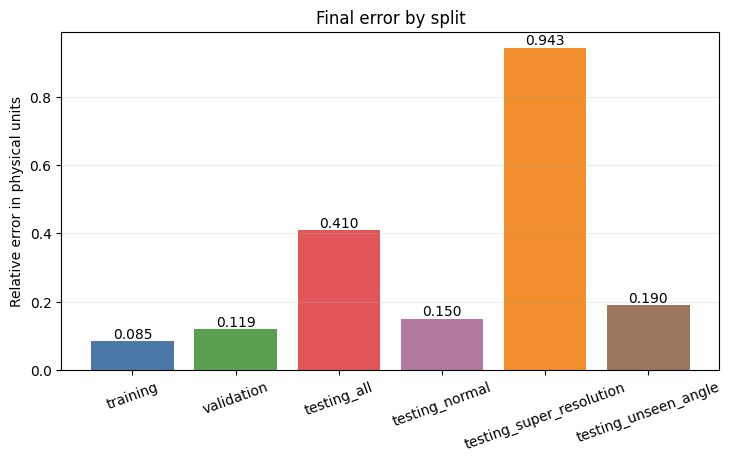

Saved: C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\final-2\output\task1_v3_analysis\final_relative_error_by_split.png


In [9]:
# Final metrics using the best checkpoint loaded at the end of training.
# Empty validation/testing splits are skipped while those cases are still being generated.

final_particle_cap = settings['particles_per_frame_final']
final_metrics = {}
final_metrics['training'] = evaluate_model(training_loader, maximum_frames=12, particle_cap=final_particle_cap)
if len(validation_dataset) > 0:
    final_metrics['validation'] = evaluate_model(validation_loader, maximum_frames=20, particle_cap=final_particle_cap)
if len(testing_dataset) > 0:
    final_metrics['testing_all'] = evaluate_model(testing_loader, maximum_frames=20, particle_cap=final_particle_cap)
if len(testing_normal_dataset) > 0:
    final_metrics['testing_normal'] = evaluate_model(testing_normal_loader, maximum_frames=20, particle_cap=final_particle_cap)
if len(testing_super_resolution_dataset) > 0:
    final_metrics['testing_super_resolution'] = evaluate_model(testing_super_resolution_loader, maximum_frames=20, particle_cap=final_particle_cap)
if len(testing_unseen_angle_dataset) > 0:
    final_metrics['testing_unseen_angle'] = evaluate_model(testing_unseen_angle_loader, maximum_frames=20, particle_cap=final_particle_cap)

print(json.dumps(final_metrics, indent=2))

figure, axis = plt.subplots(figsize=(7.2, 4.5), constrained_layout=True)
split_names = list(final_metrics.keys())
values = [final_metrics[name]['relative_error'] for name in split_names]
metric_colors = ['#4c78a8', '#59a14f', '#e15759', '#b07aa1', '#f28e2b', '#9c755f']
bars = axis.bar(split_names, values, color=metric_colors[:len(split_names)])
axis.tick_params(axis='x', rotation=20)
axis.set_ylabel('Relative error in physical units')
axis.set_title('Final error by split')
axis.grid(axis='y', alpha=0.25)
for bar, value in zip(bars, values):
    axis.text(bar.get_x() + bar.get_width() / 2, value, f'{value:.3f}', ha='center', va='bottom')
plot_path = results_folder / 'final_relative_error_by_split.png'
figure.savefig(plot_path, dpi=220, bbox_inches='tight')
plt.show()
print('Saved:', plot_path)


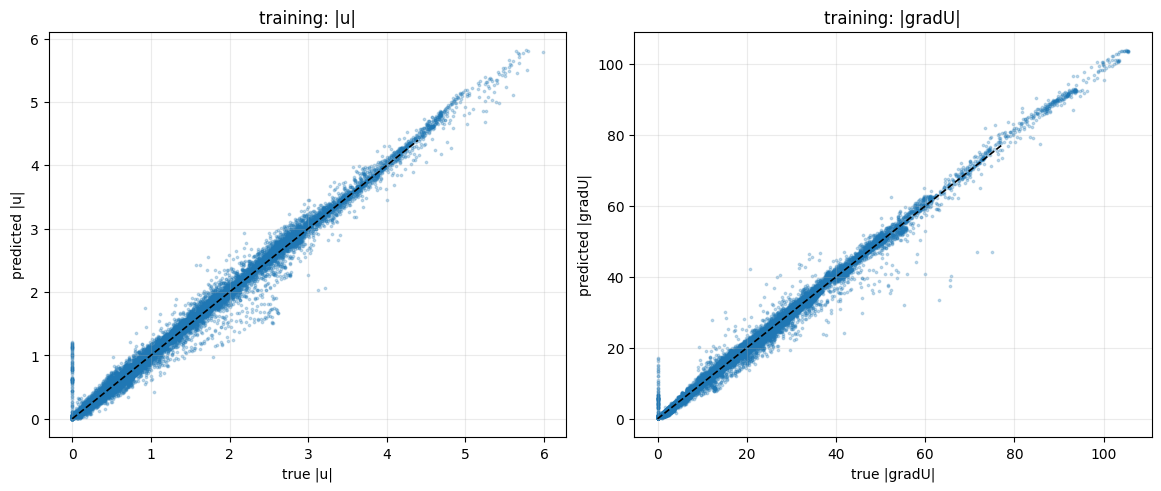

Saved: C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\final-2\output\task1_v3_analysis\training_prediction_scatter.png


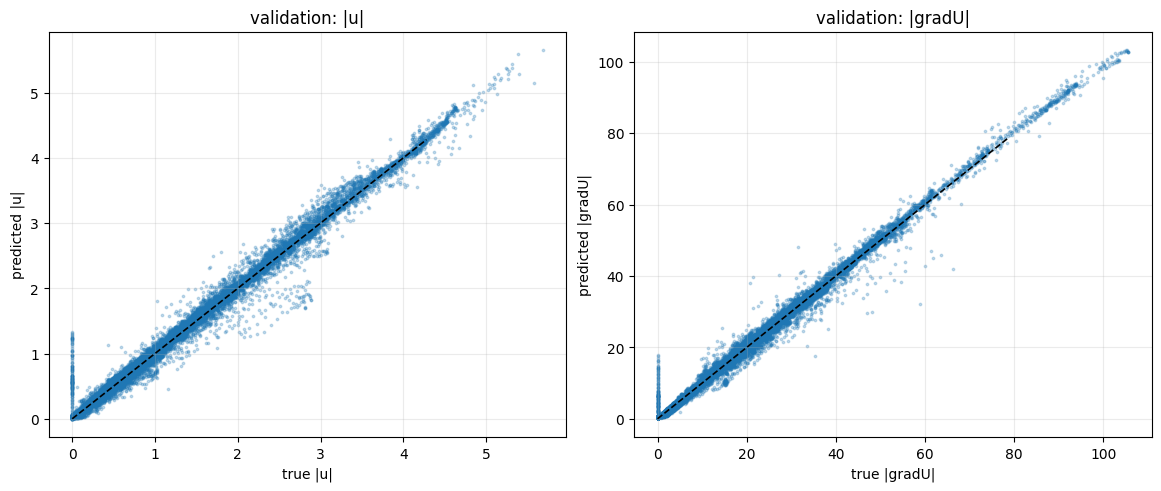

Saved: C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\final-2\output\task1_v3_analysis\validation_prediction_scatter.png


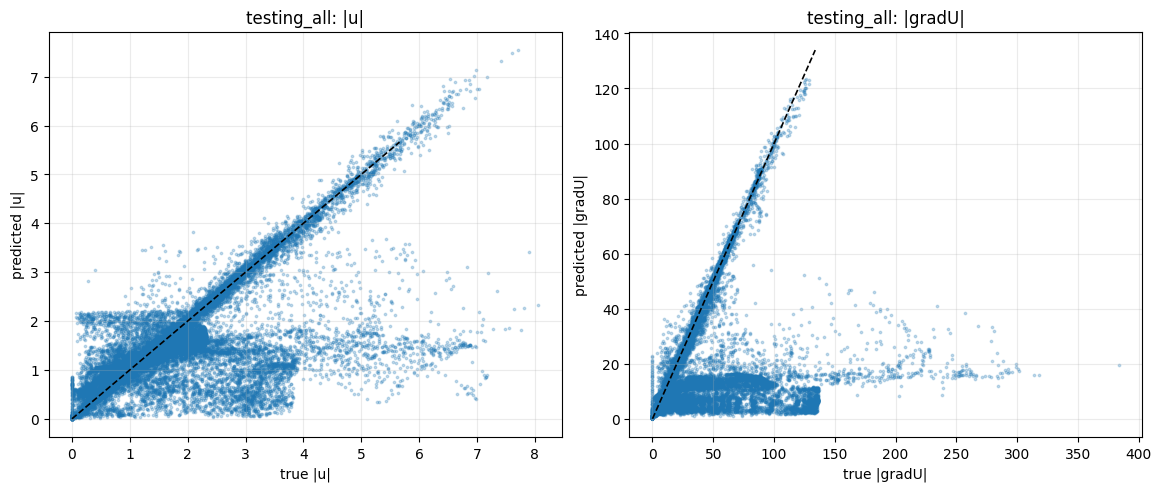

Saved: C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\final-2\output\task1_v3_analysis\testing_all_prediction_scatter.png


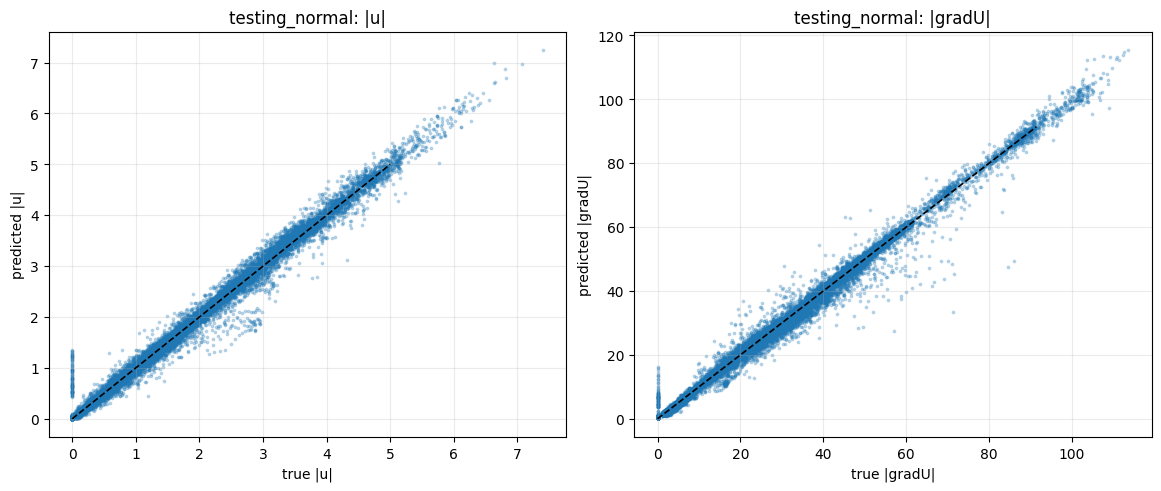

Saved: C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\final-2\output\task1_v3_analysis\testing_normal_prediction_scatter.png


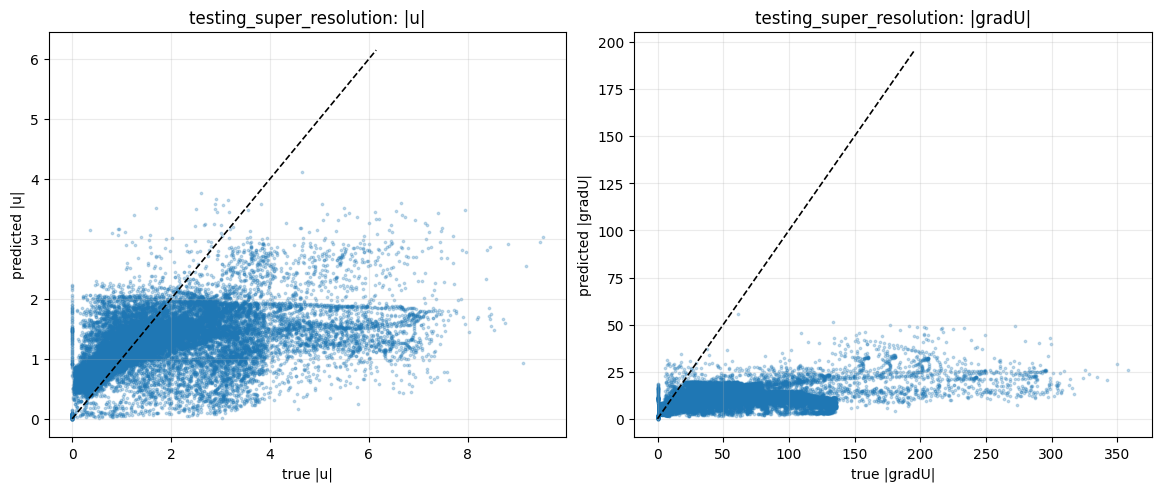

Saved: C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\final-2\output\task1_v3_analysis\testing_super_resolution_prediction_scatter.png


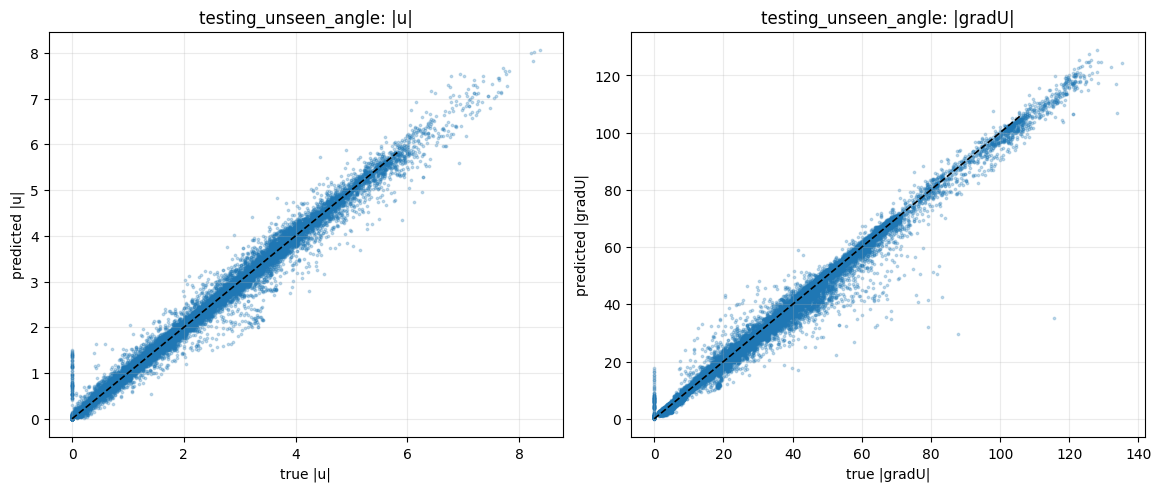

Saved: C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\final-2\output\task1_v3_analysis\testing_unseen_angle_prediction_scatter.png


In [10]:
# Prediction-versus-true scatter plots.
# These are often more revealing than loss alone: diagonal alignment means good magnitude prediction.

@torch.no_grad()
def collect_prediction_samples(dataset, maximum_frames=6, maximum_particles_per_frame=5000):
    if len(dataset) == 0:
        return None, None
    true_chunks = []
    predicted_chunks = []

    for dataset_index in sample_dataset_indices(dataset, maximum_frames, seed_offset=79):
        input_tensor, target_tensor, raw_input_tensor, metadata = dataset[dataset_index]
        input_tensor, target_tensor, raw_input_tensor = subsample_before_gpu(
            input_tensor, target_tensor, raw_input_tensor, maximum_particles_per_frame
        )
        prediction_normalized = model(input_tensor.to(device)).float()
        true_physical = denormalize_target(target_tensor.to(device)).cpu().numpy()
        predicted_physical = denormalize_target(prediction_normalized).cpu().numpy()
        true_chunks.append(true_physical)
        predicted_chunks.append(predicted_physical)

    return np.concatenate(true_chunks, axis=0), np.concatenate(predicted_chunks, axis=0)


def plot_scatter_for_split(split_name, dataset):
    true_values, predicted_values = collect_prediction_samples(dataset)
    if true_values is None:
        print(f'[{split_name}] no data available; skipping scatter plot.')
        return

    true_velocity = np.linalg.norm(true_values[:, :3], axis=1)
    predicted_velocity = np.linalg.norm(predicted_values[:, :3], axis=1)
    true_gradient = np.linalg.norm(true_values[:, 3:], axis=1)
    predicted_gradient = np.linalg.norm(predicted_values[:, 3:], axis=1)

    figure, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), constrained_layout=True)
    for axis, true_array, predicted_array, title in [
        (axes[0], true_velocity, predicted_velocity, '|u|'),
        (axes[1], true_gradient, predicted_gradient, '|gradU|'),
    ]:
        if true_array.shape[0] > 30000:
            picked = np.random.default_rng(SEED).choice(true_array.shape[0], size=30000, replace=False)
            true_array = true_array[picked]
            predicted_array = predicted_array[picked]
        low = float(np.quantile(np.concatenate([true_array, predicted_array]), 0.01))
        high = float(np.quantile(np.concatenate([true_array, predicted_array]), 0.99))
        axis.scatter(true_array, predicted_array, s=3, alpha=0.25)
        axis.plot([low, high], [low, high], color='black', linewidth=1.2, linestyle='--')
        axis.set_xlabel(f'true {title}')
        axis.set_ylabel(f'predicted {title}')
        axis.set_title(f'{split_name}: {title}')
        axis.grid(alpha=0.25)

    plot_path = results_folder / f'{split_name.lower()}_prediction_scatter.png'
    figure.savefig(plot_path, dpi=220, bbox_inches='tight')
    plt.show()
    print('Saved:', plot_path)


plot_scatter_for_split('training', training_dataset)
plot_scatter_for_split('validation', validation_dataset)
plot_scatter_for_split('testing_all', testing_dataset)
plot_scatter_for_split('testing_normal', testing_normal_dataset)
plot_scatter_for_split('testing_super_resolution', testing_super_resolution_dataset)
plot_scatter_for_split('testing_unseen_angle', testing_unseen_angle_dataset)


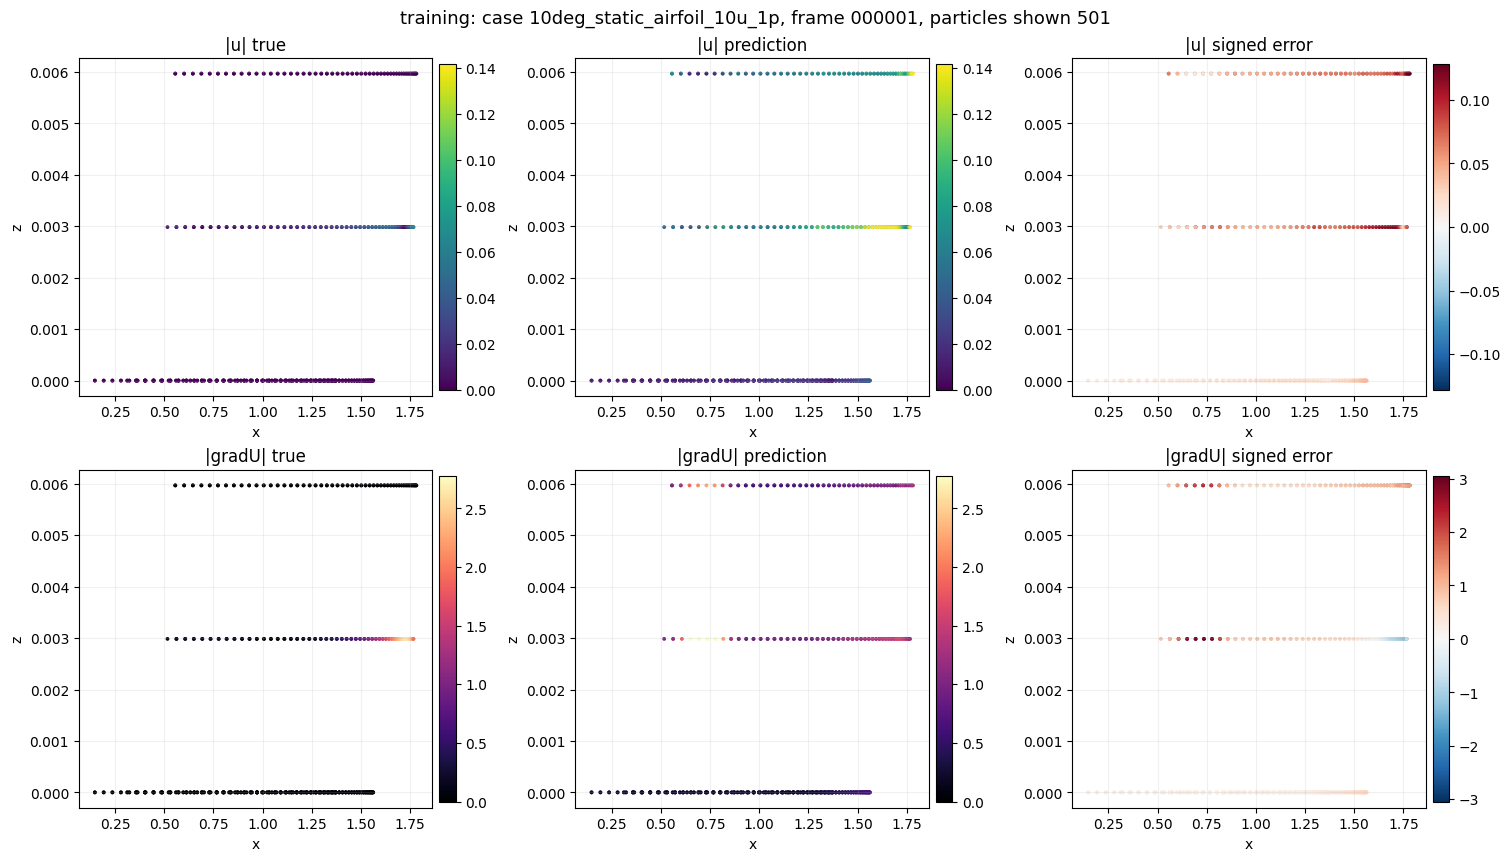

Saved: C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\final-2\output\task1_v3_analysis\training_prediction_example.png


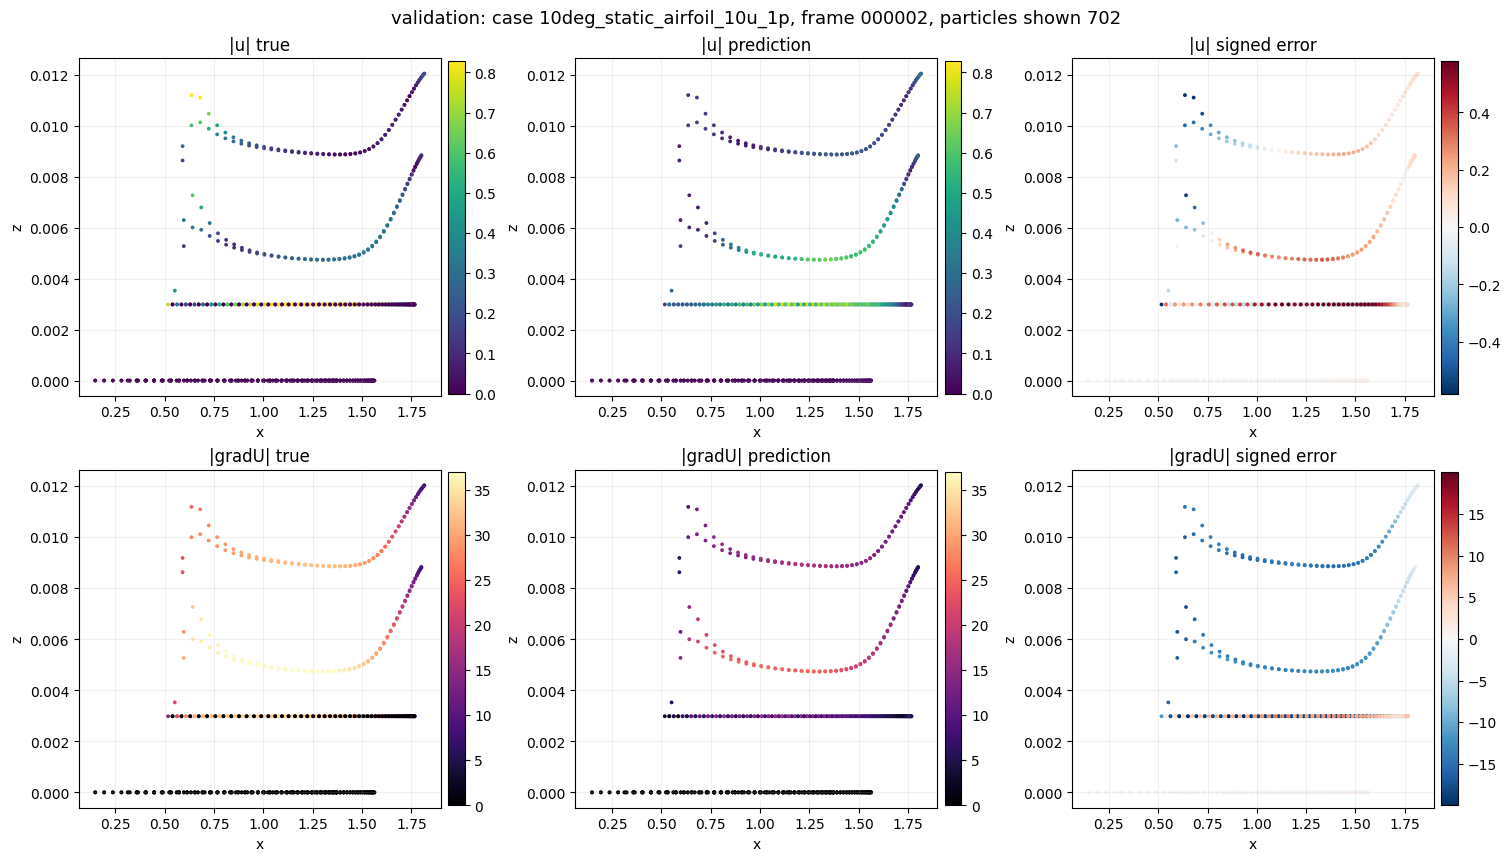

Saved: C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\final-2\output\task1_v3_analysis\validation_prediction_example.png


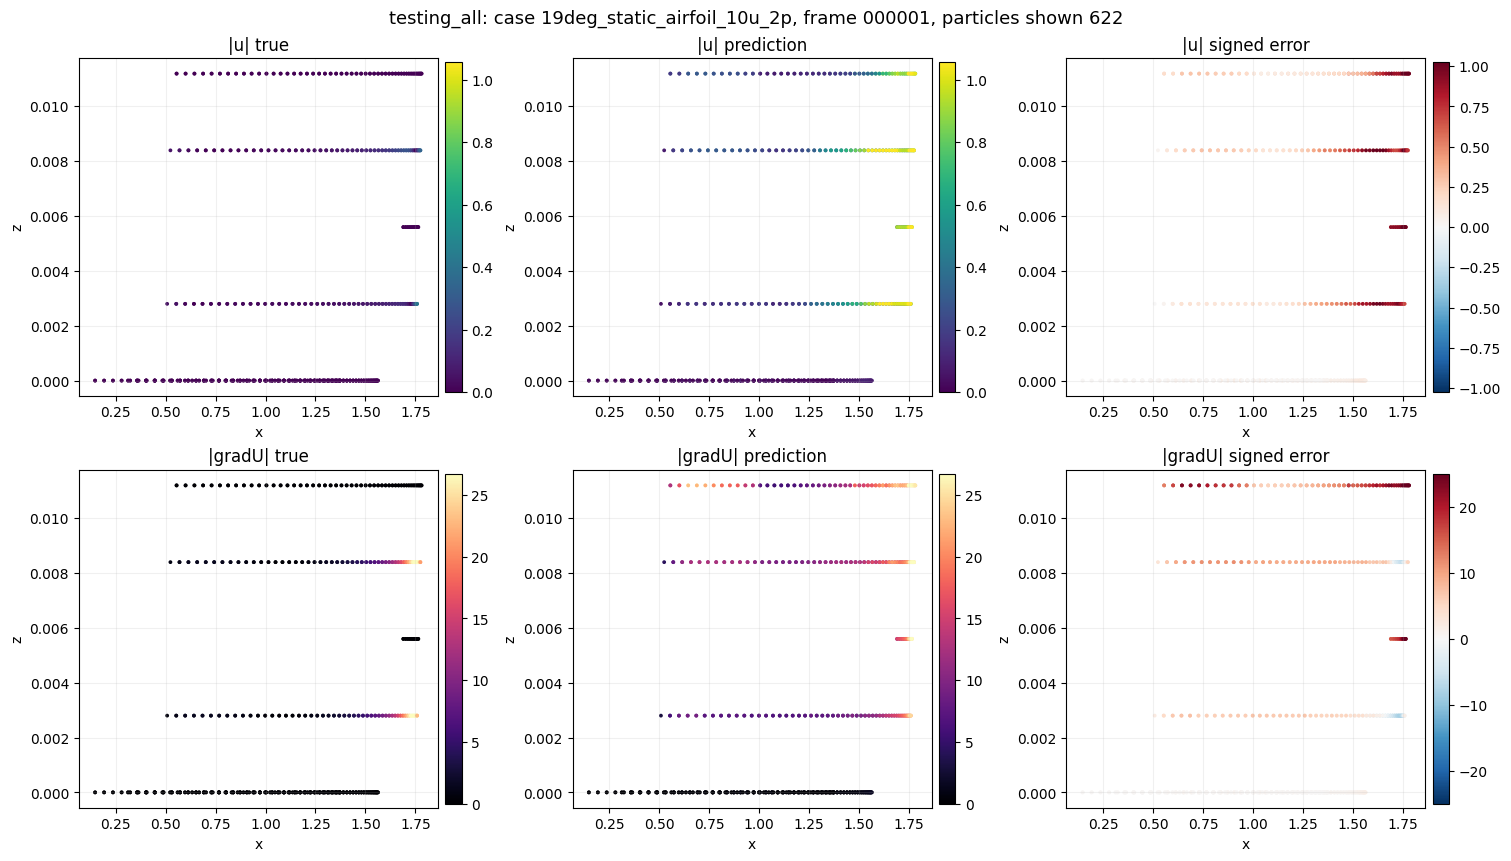

Saved: C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\final-2\output\task1_v3_analysis\testing_all_prediction_example.png


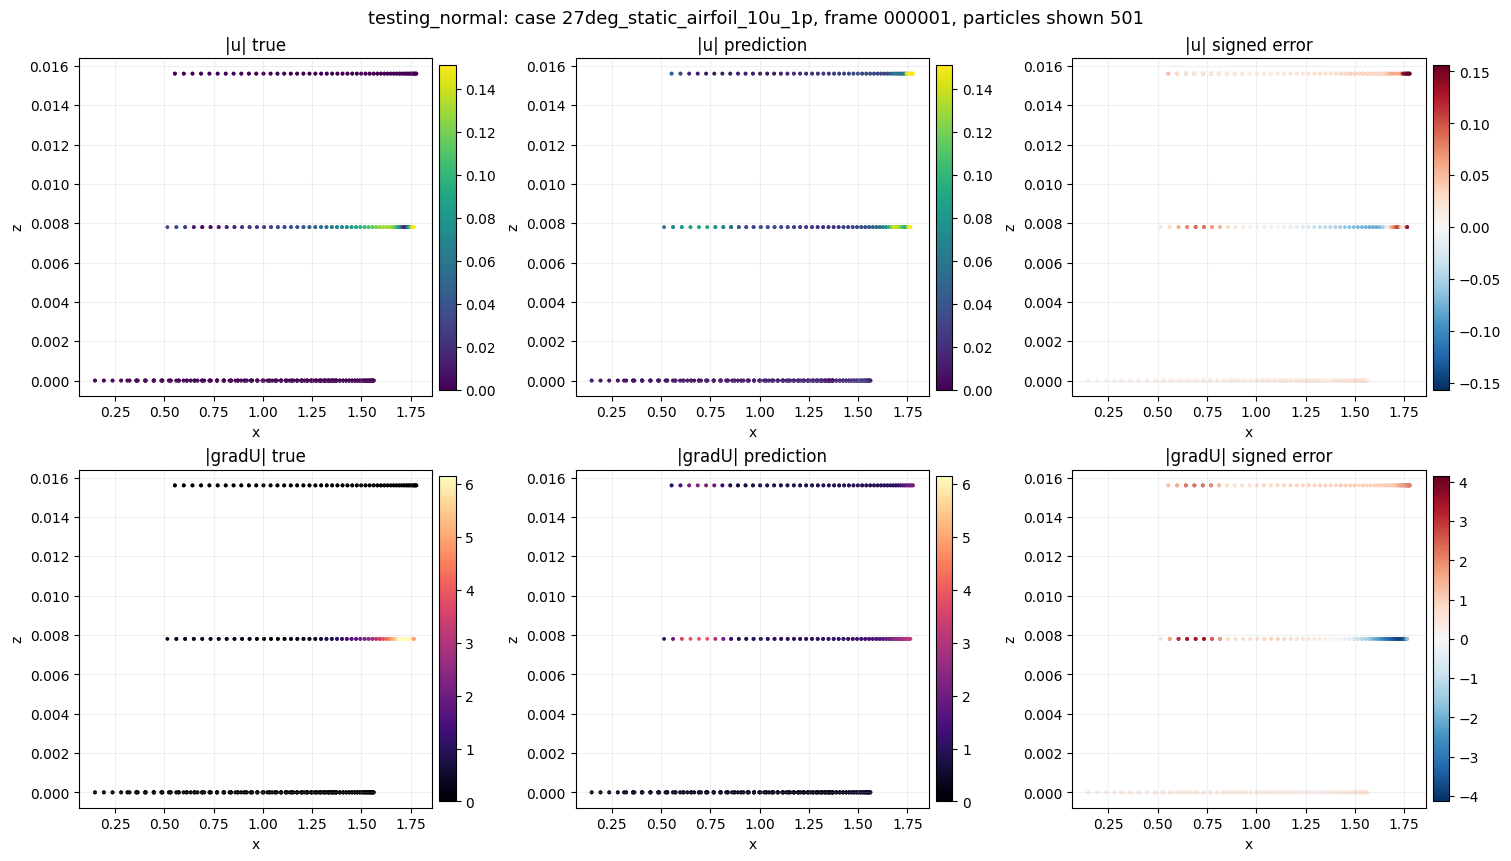

Saved: C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\final-2\output\task1_v3_analysis\testing_normal_prediction_example.png


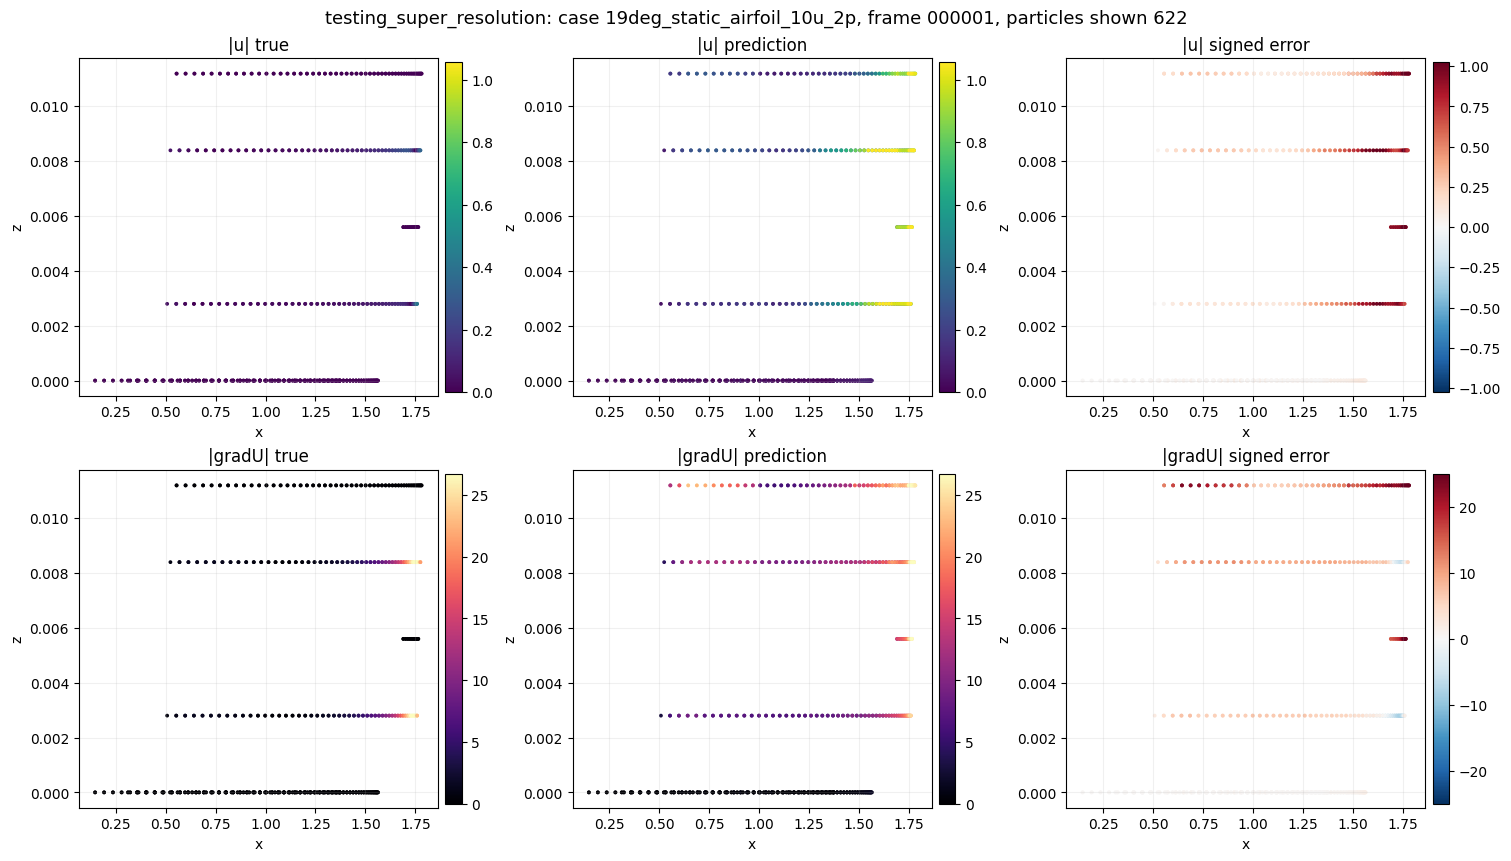

Saved: C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\final-2\output\task1_v3_analysis\testing_super_resolution_prediction_example.png


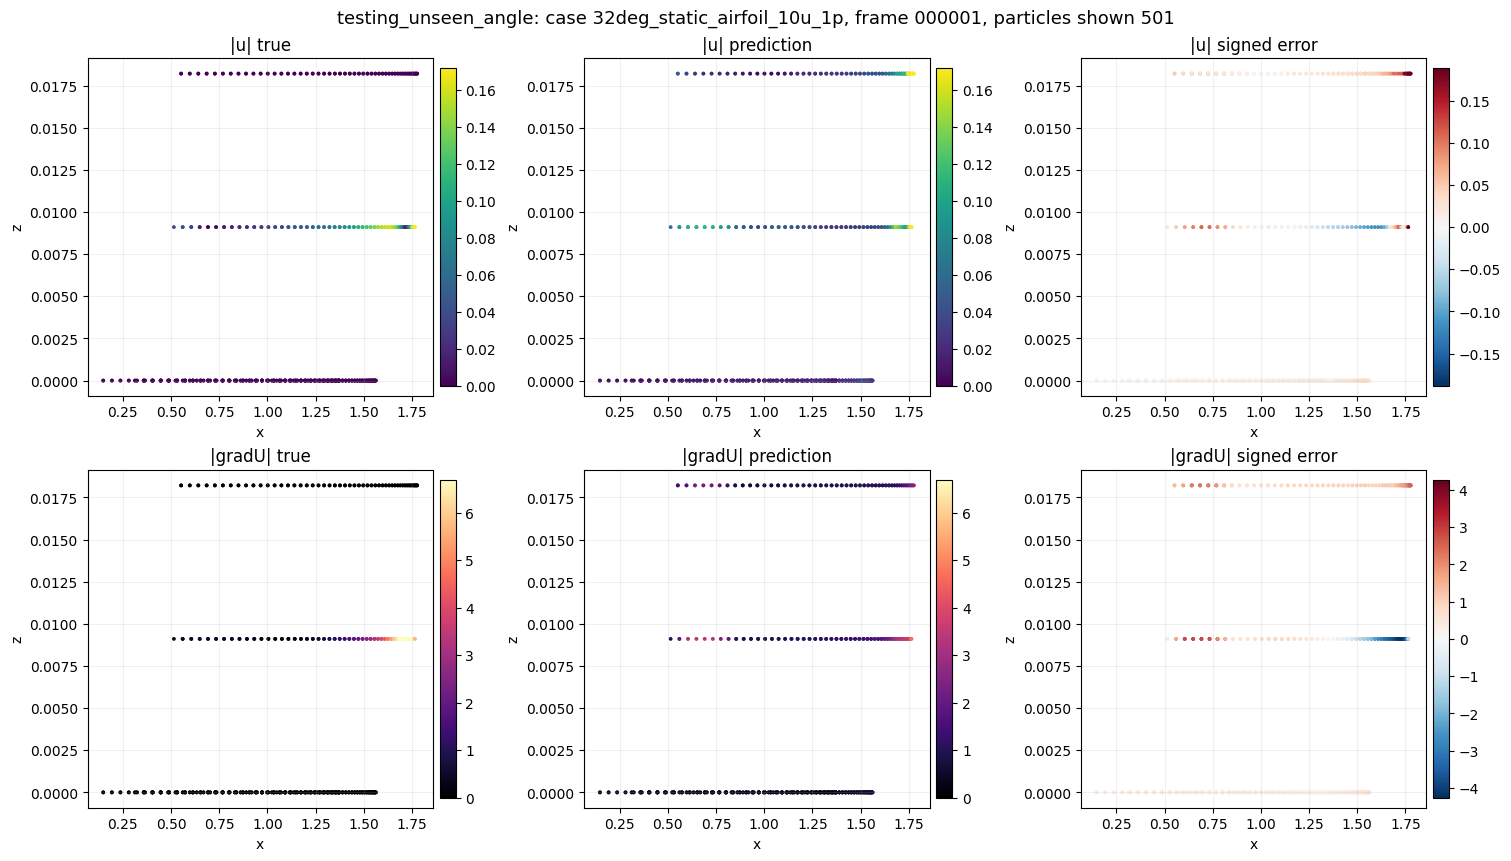

Saved: C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\final-2\output\task1_v3_analysis\testing_unseen_angle_prediction_example.png


In [11]:
# Prediction plots for training, validation, and testing.
# Coordinates are input particle locations. The model predicts velocity and velocity gradient values on those particles.

@torch.no_grad()
def predict_one_frame(dataset, dataset_index=0, maximum_particles_for_plot=12000):
    model.eval()
    input_tensor, target_tensor, raw_input_tensor, metadata = dataset[dataset_index]
    input_tensor, target_tensor, raw_input_tensor = subsample_before_gpu(
        input_tensor, target_tensor, raw_input_tensor, maximum_particles_for_plot
    )
    prediction_normalized = model(input_tensor.to(device)).float()
    target_physical = denormalize_target(target_tensor.to(device)).cpu().numpy()
    prediction_physical = denormalize_target(prediction_normalized).cpu().numpy()
    raw_input = raw_input_tensor.numpy()
    return raw_input[:, :3], target_physical, prediction_physical, metadata


def robust_color_limits(values, lower=0.02, upper=0.98):
    finite_values = np.asarray(values)[np.isfinite(values)]
    if finite_values.size == 0:
        return 0.0, 1.0
    low = float(np.quantile(finite_values, lower))
    high = float(np.quantile(finite_values, upper))
    if low >= high:
        high = low + 1e-6
    return low, high


def plot_prediction_example(split_name, dataset, dataset_index=0):
    coordinates, true_values, predicted_values, metadata = predict_one_frame(dataset, dataset_index=dataset_index)

    true_velocity = np.linalg.norm(true_values[:, :3], axis=1)
    predicted_velocity = np.linalg.norm(predicted_values[:, :3], axis=1)
    velocity_error = predicted_velocity - true_velocity

    true_gradient = np.linalg.norm(true_values[:, 3:], axis=1)
    predicted_gradient = np.linalg.norm(predicted_values[:, 3:], axis=1)
    gradient_error = predicted_gradient - true_gradient

    figure, axes = plt.subplots(2, 3, figsize=(15, 8.5), constrained_layout=True)

    velocity_low, velocity_high = robust_color_limits(np.concatenate([true_velocity, predicted_velocity]))
    gradient_low, gradient_high = robust_color_limits(np.concatenate([true_gradient, predicted_gradient]))
    velocity_error_limit = max(abs(robust_color_limits(velocity_error)[0]), abs(robust_color_limits(velocity_error)[1]), 1e-12)
    gradient_error_limit = max(abs(robust_color_limits(gradient_error)[0]), abs(robust_color_limits(gradient_error)[1]), 1e-12)

    plot_items = [
        (0, 0, true_velocity, '|u| true', 'viridis', velocity_low, velocity_high),
        (0, 1, predicted_velocity, '|u| prediction', 'viridis', velocity_low, velocity_high),
        (0, 2, velocity_error, '|u| signed error', 'RdBu_r', -velocity_error_limit, velocity_error_limit),
        (1, 0, true_gradient, '|gradU| true', 'magma', gradient_low, gradient_high),
        (1, 1, predicted_gradient, '|gradU| prediction', 'magma', gradient_low, gradient_high),
        (1, 2, gradient_error, '|gradU| signed error', 'RdBu_r', -gradient_error_limit, gradient_error_limit),
    ]

    for row, column, values, title, color_map, low, high in plot_items:
        scatter = axes[row, column].scatter(
            coordinates[:, 0], coordinates[:, 2], c=values, s=3, cmap=color_map, vmin=low, vmax=high
        )
        axes[row, column].set_title(title)
        axes[row, column].set_xlabel('x')
        axes[row, column].set_ylabel('z')
        axes[row, column].grid(alpha=0.18)
        plt.colorbar(scatter, ax=axes[row, column], fraction=0.046, pad=0.02)

    figure.suptitle(
        f"{split_name}: case {metadata['case']}, frame {metadata['frame']}, particles shown {coordinates.shape[0]}",
        fontsize=13,
    )
    plot_path = results_folder / f'{split_name.lower()}_prediction_example.png'
    figure.savefig(plot_path, dpi=240, bbox_inches='tight')
    plt.show()
    print('Saved:', plot_path)


plot_prediction_example('training', training_dataset, dataset_index=0)
if len(validation_dataset) > 0:
    plot_prediction_example('validation', validation_dataset, dataset_index=0)
else:
    print('[validation] no data available; skipping prediction image.')
for split_name, split_dataset in [
    ('testing_all', testing_dataset),
    ('testing_normal', testing_normal_dataset),
    ('testing_super_resolution', testing_super_resolution_dataset),
    ('testing_unseen_angle', testing_unseen_angle_dataset),
]:
    if len(split_dataset) > 0:
        plot_prediction_example(split_name, split_dataset, dataset_index=0)
    else:
        print(f'[{split_name}] no data available; skipping prediction image.')


# Temporal target trace for one particle

This cell picks one training case and one testing case, then tracks the same particle index through time. It plots normalized target magnitudes for velocity `u` and velocity gradient `gradU`.


Train case: 10deg_static_airfoil_10u_1p | frames used: 160
Test case : 32deg_static_airfoil_10u_1p (testing_unseen_angle) | frames used: 200
Particle index used for all plots: 0


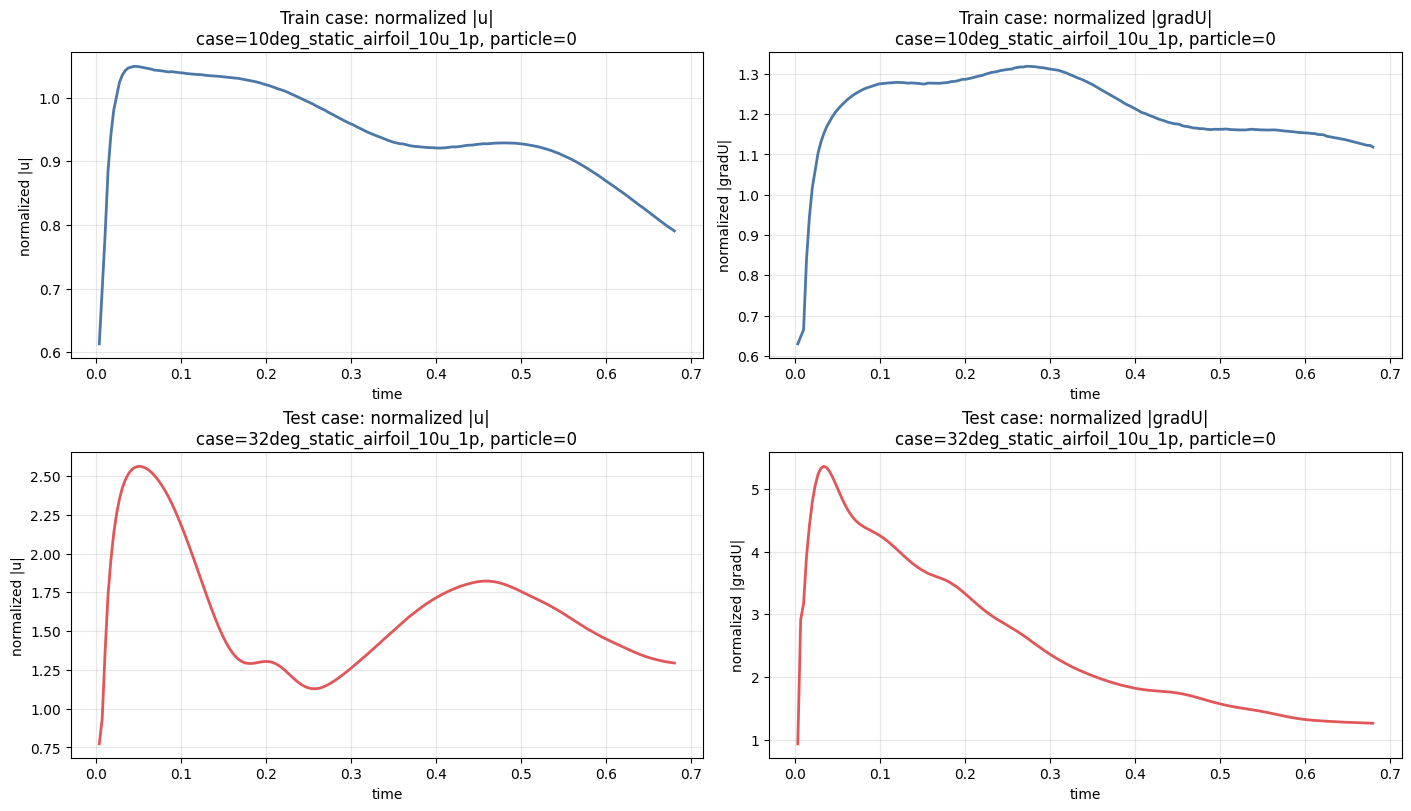

Saved: C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\final-2\output\task1_v3_analysis\temporal_particle_0_normalized_u_gradU.png


In [12]:
# Temporal variation of normalized u and gradU for one fixed particle index.
# This uses the same metadata convention as the rest of this notebook: frame_context['case'].

# Choose one train case automatically. You can replace this string manually if needed.
available_training_cases = sorted({frame_context_as_dict(int(frame_id)).get('case', 'unknown') for frame_id in training_frame_ids})
if len(available_training_cases) == 0:
    raise RuntimeError('No training cases available for temporal plotting.')
train_case_name = available_training_cases[0]

# Choose one test source. Change this to testing_normal_frame_ids or testing_super_resolution_frame_ids if desired.
test_frames_source = testing_unseen_angle_frame_ids

test_source_name = 'testing_unseen_angle'
if len(test_frames_source) == 0:
    # Fall back to the combined test set if the selected test split is empty.
    test_frames_source = testing_frame_ids
    test_source_name = 'testing_all'

# One fixed particle index is used for all four plots.
# If this particle index does not exist in an early frame, that frame is skipped.
particle_index = 0


def case_name_for_frame(frame_id):
    # Older snippets used 'case_name', but this notebook stores the key as 'case'.
    context = frame_context_as_dict(int(frame_id))
    return str(context.get('case', context.get('case_name', 'unknown')))


def time_value_for_frame(frame_id):
    # Prefer physical time = frame_number * dt when dt is available.
    context = frame_context_as_dict(int(frame_id))
    frame_number = float(context.get('frame', frame_ranges[int(frame_id)][1]))
    dt = float(context.get('dt', 1.0))
    return frame_number * dt


def frame_number_for_sort(frame_id):
    return int(float(frame_context_as_dict(int(frame_id)).get('frame', frame_ranges[int(frame_id)][1])))


def frame_ids_for_case(frame_ids, case_name):
    selected = [int(frame_id) for frame_id in frame_ids if case_name_for_frame(int(frame_id)) == str(case_name)]
    return sorted(selected, key=frame_number_for_sort)


def first_case_from_frames(frame_ids):
    if len(frame_ids) == 0:
        raise RuntimeError('Cannot choose a case from an empty frame list.')
    first_frame_id = int(sorted(frame_ids, key=frame_number_for_sort)[0])
    return case_name_for_frame(first_frame_id)


train_case_frame_ids = frame_ids_for_case(training_frame_ids, train_case_name)
test_case_name = first_case_from_frames(test_frames_source)
test_case_frame_ids = frame_ids_for_case(test_frames_source, test_case_name)

if len(train_case_frame_ids) == 0:
    raise RuntimeError(f'No frames found for training case: {train_case_name}')
if len(test_case_frame_ids) == 0:
    raise RuntimeError(f'No frames found for test case: {test_case_name}')


def extract_temporal_target_series(frame_ids, arrays_by_frame, particle_index):
    # arrays_by_frame should be targets_by_frame_normalized here.
    # Target channel order is [u_x, u_y, u_z, gradU_11, ..., gradU_33].
    time_values = []
    velocity_magnitudes = []
    gradient_magnitudes = []
    used_frame_numbers = []

    for frame_id in frame_ids:
        target_frame = arrays_by_frame[int(frame_id)]
        if particle_index >= target_frame.shape[0]:
            continue

        particle_target = target_frame[particle_index]
        velocity_magnitude = np.linalg.norm(particle_target[:3])
        gradient_magnitude = np.linalg.norm(particle_target[3:12])

        time_values.append(time_value_for_frame(frame_id))
        velocity_magnitudes.append(velocity_magnitude)
        gradient_magnitudes.append(gradient_magnitude)
        used_frame_numbers.append(frame_number_for_sort(frame_id))

    if len(time_values) == 0:
        raise RuntimeError(
            f'particle_index={particle_index} was not available in any selected frame. '
            'Try particle_index=0 or a smaller index.'
        )

    return {
        'time': np.asarray(time_values, dtype=np.float64),
        'velocity': np.asarray(velocity_magnitudes, dtype=np.float64),
        'gradient': np.asarray(gradient_magnitudes, dtype=np.float64),
        'frame': np.asarray(used_frame_numbers, dtype=np.int64),
    }


train_series = extract_temporal_target_series(train_case_frame_ids, targets_by_frame_normalized, particle_index)
test_series = extract_temporal_target_series(test_case_frame_ids, targets_by_frame_normalized, particle_index)

print('Train case:', train_case_name, '| frames used:', len(train_series['time']))
print('Test case :', test_case_name, f'({test_source_name})', '| frames used:', len(test_series['time']))
print('Particle index used for all plots:', particle_index)

figure, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

axes[0, 0].plot(train_series['time'], train_series['velocity'], linewidth=2.0, color='#4c78a8')
axes[0, 0].set_title(f'Train case: normalized |u|\ncase={train_case_name}, particle={particle_index}')
axes[0, 0].set_xlabel('time')
axes[0, 0].set_ylabel('normalized |u|')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(train_series['time'], train_series['gradient'], linewidth=2.0, color='#4c78a8')
axes[0, 1].set_title(f'Train case: normalized |gradU|\ncase={train_case_name}, particle={particle_index}')
axes[0, 1].set_xlabel('time')
axes[0, 1].set_ylabel('normalized |gradU|')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(test_series['time'], test_series['velocity'], linewidth=2.0, color='#e15759')
axes[1, 0].set_title(f'Test case: normalized |u|\ncase={test_case_name}, particle={particle_index}')
axes[1, 0].set_xlabel('time')
axes[1, 0].set_ylabel('normalized |u|')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(test_series['time'], test_series['gradient'], linewidth=2.0, color='#e15759')
axes[1, 1].set_title(f'Test case: normalized |gradU|\ncase={test_case_name}, particle={particle_index}')
axes[1, 1].set_xlabel('time')
axes[1, 1].set_ylabel('normalized |gradU|')
axes[1, 1].grid(alpha=0.3)

plot_path = results_folder / f'temporal_particle_{particle_index}_normalized_u_gradU.png'
figure.savefig(plot_path, dpi=220, bbox_inches='tight')
plt.show()
print('Saved:', plot_path)


# Temporal input-feature trace for one particle

This cell mirrors the `u`/`gradU` temporal plot, but for input features. It tracks one fixed particle index through one training case and one testing case, then plots position, Gamma-vector components, and sigma versus time.


Input temporal plot values: raw input
Train case: 10deg_static_airfoil_10u_1p | frames used: 160
Test case : 32deg_static_airfoil_10u_1p (testing_unseen_angle) | frames used: 200
Particle index used: 0


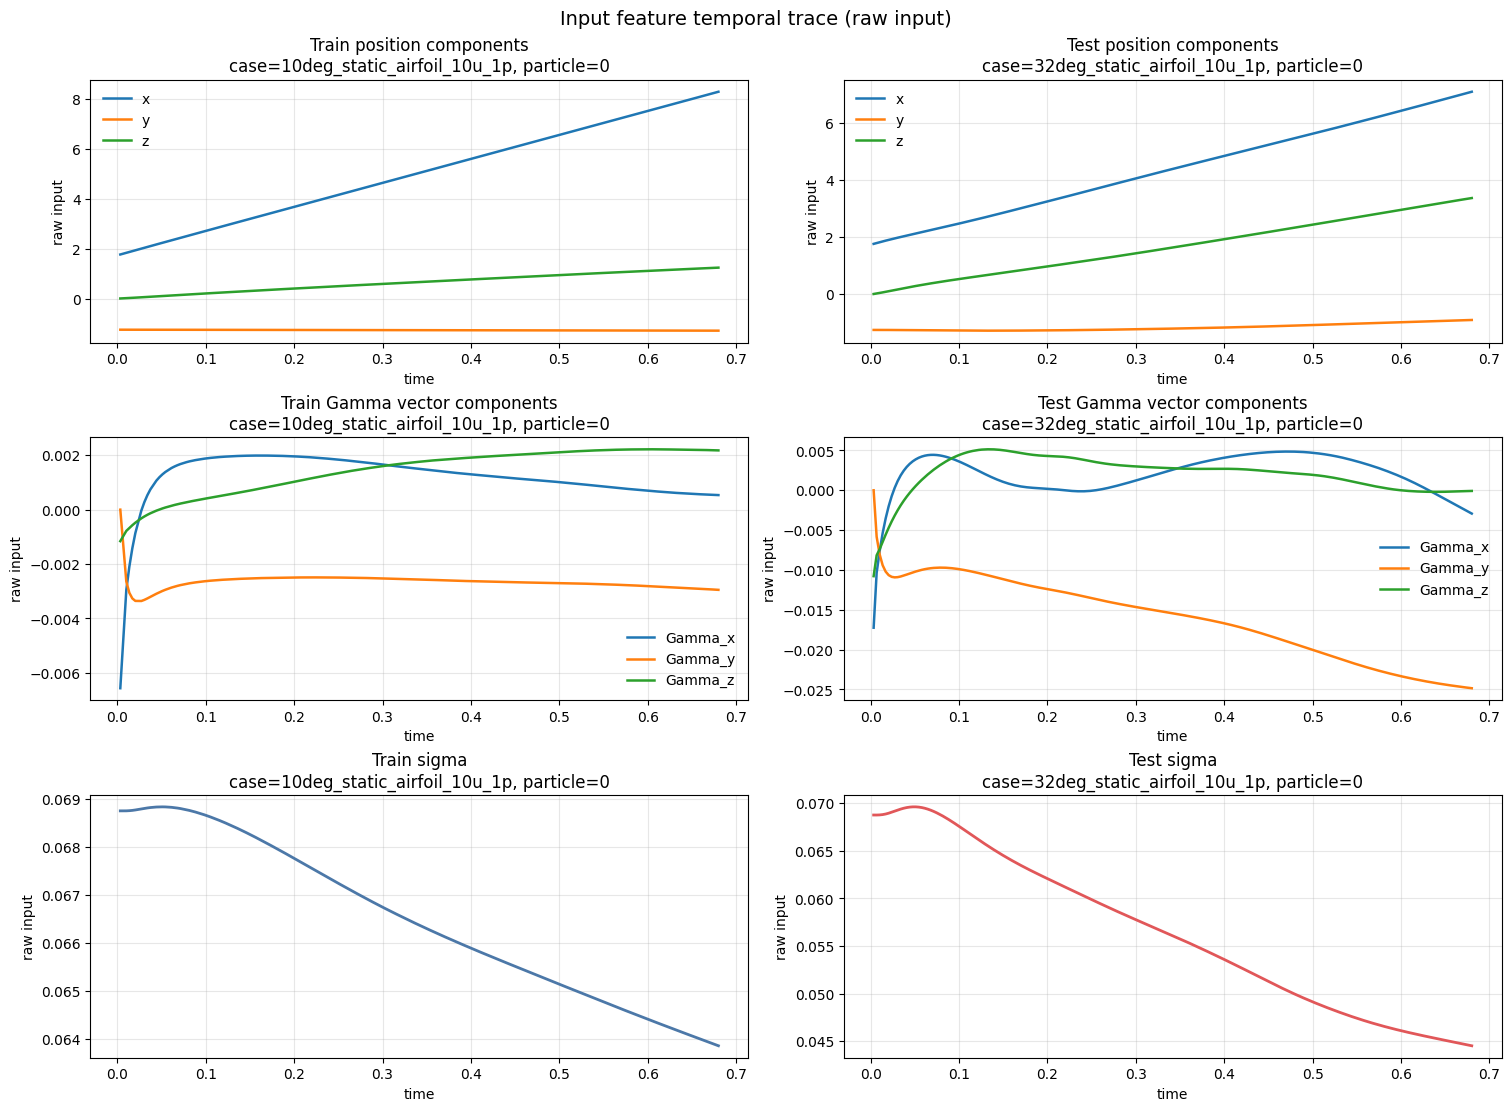

Saved: C:\Users\TCZ\Desktop\Neeraj\Flow-reconstruction-in-VPM-using-FNO-main\final-2\output\task1_v3_analysis\temporal_particle_0_input_features.png


In [13]:
# Temporal variation of input features for one fixed particle index.
# This is for visualization only; it helps check what the GNO sees as particle input over time.

# Choose whether to visualize raw physical/preprocessed input values or normalized model inputs.
use_normalized_inputs_for_temporal_plot = False
input_arrays_for_temporal_plot = inputs_by_frame_normalized if use_normalized_inputs_for_temporal_plot else inputs_by_frame_raw
input_value_label = 'normalized input' if use_normalized_inputs_for_temporal_plot else 'raw input'

# Reuse the same convention as the target temporal plot.
available_training_cases = sorted({frame_context_as_dict(int(frame_id)).get('case', 'unknown') for frame_id in training_frame_ids})
if len(available_training_cases) == 0:
    raise RuntimeError('No training cases available for temporal input plotting.')
train_case_name = available_training_cases[0]

test_frames_source = testing_unseen_angle_frame_ids
test_source_name = 'testing_unseen_angle'
if len(test_frames_source) == 0:
    test_frames_source = testing_frame_ids
    test_source_name = 'testing_all'

particle_index = 0


def input_feature_index(name):
    if name not in feature_names:
        raise RuntimeError(f'Missing required input feature {name!r}. Available features: {feature_names}')
    return feature_names.index(name)


position_feature_indices = [input_feature_index(name) for name in ['x', 'y', 'z']]
gamma_feature_indices = [input_feature_index(name) for name in ['Gamma_x', 'Gamma_y', 'Gamma_z']]
sigma_feature_index = input_feature_index('sigma')


def case_name_for_frame_safe(frame_id):
    context = frame_context_as_dict(int(frame_id))
    return str(context.get('case', context.get('case_name', 'unknown')))


def frame_number_for_sort_safe(frame_id):
    context = frame_context_as_dict(int(frame_id))
    return int(float(context.get('frame', frame_ranges[int(frame_id)][1])))


def time_value_for_frame_safe(frame_id):
    context = frame_context_as_dict(int(frame_id))
    frame_number = float(context.get('frame', frame_ranges[int(frame_id)][1]))
    dt = float(context.get('dt', 1.0))
    return frame_number * dt


def frame_ids_for_case_safe(frame_ids, case_name):
    selected = [int(frame_id) for frame_id in frame_ids if case_name_for_frame_safe(int(frame_id)) == str(case_name)]
    return sorted(selected, key=frame_number_for_sort_safe)


def first_case_from_frames_safe(frame_ids):
    if len(frame_ids) == 0:
        raise RuntimeError('Cannot choose a case from an empty frame list.')
    first_frame_id = int(sorted(frame_ids, key=frame_number_for_sort_safe)[0])
    return case_name_for_frame_safe(first_frame_id)


train_case_frame_ids = frame_ids_for_case_safe(training_frame_ids, train_case_name)
test_case_name = first_case_from_frames_safe(test_frames_source)
test_case_frame_ids = frame_ids_for_case_safe(test_frames_source, test_case_name)


def extract_temporal_input_series(frame_ids, arrays_by_frame, particle_index):
    time_values = []
    position_values = []
    gamma_values = []
    sigma_values = []

    for frame_id in frame_ids:
        input_frame = arrays_by_frame[int(frame_id)]
        if particle_index >= input_frame.shape[0]:
            continue

        particle_input = input_frame[particle_index]
        time_values.append(time_value_for_frame_safe(frame_id))
        position_values.append(particle_input[position_feature_indices])
        gamma_values.append(particle_input[gamma_feature_indices])
        sigma_values.append(particle_input[sigma_feature_index])

    if len(time_values) == 0:
        raise RuntimeError(
            f'particle_index={particle_index} was not available in any selected frame. '
            'Try a smaller particle_index.'
        )

    return {
        'time': np.asarray(time_values, dtype=np.float64),
        'position': np.asarray(position_values, dtype=np.float64),
        'gamma': np.asarray(gamma_values, dtype=np.float64),
        'sigma': np.asarray(sigma_values, dtype=np.float64),
    }


train_input_series = extract_temporal_input_series(train_case_frame_ids, input_arrays_for_temporal_plot, particle_index)
test_input_series = extract_temporal_input_series(test_case_frame_ids, input_arrays_for_temporal_plot, particle_index)

print('Input temporal plot values:', input_value_label)
print('Train case:', train_case_name, '| frames used:', len(train_input_series['time']))
print('Test case :', test_case_name, f'({test_source_name})', '| frames used:', len(test_input_series['time']))
print('Particle index used:', particle_index)

figure, axes = plt.subplots(3, 2, figsize=(15, 11), constrained_layout=True)
component_labels = ['x', 'y', 'z']
gamma_labels = ['Gamma_x', 'Gamma_y', 'Gamma_z']

for component_id, label in enumerate(component_labels):
    axes[0, 0].plot(train_input_series['time'], train_input_series['position'][:, component_id], linewidth=1.8, label=label)
    axes[0, 1].plot(test_input_series['time'], test_input_series['position'][:, component_id], linewidth=1.8, label=label)

axes[0, 0].set_title(f'Train position components\ncase={train_case_name}, particle={particle_index}')
axes[0, 1].set_title(f'Test position components\ncase={test_case_name}, particle={particle_index}')

for component_id, label in enumerate(gamma_labels):
    axes[1, 0].plot(train_input_series['time'], train_input_series['gamma'][:, component_id], linewidth=1.8, label=label)
    axes[1, 1].plot(test_input_series['time'], test_input_series['gamma'][:, component_id], linewidth=1.8, label=label)

axes[1, 0].set_title(f'Train Gamma vector components\ncase={train_case_name}, particle={particle_index}')
axes[1, 1].set_title(f'Test Gamma vector components\ncase={test_case_name}, particle={particle_index}')

axes[2, 0].plot(train_input_series['time'], train_input_series['sigma'], linewidth=2.0, color='#4c78a8')
axes[2, 1].plot(test_input_series['time'], test_input_series['sigma'], linewidth=2.0, color='#e15759')
axes[2, 0].set_title(f'Train sigma\ncase={train_case_name}, particle={particle_index}')
axes[2, 1].set_title(f'Test sigma\ncase={test_case_name}, particle={particle_index}')

for axis in axes.reshape(-1):
    axis.set_xlabel('time')
    axis.set_ylabel(input_value_label)
    axis.grid(alpha=0.3)
    if len(axis.get_lines()) > 1:
        axis.legend(frameon=False)

figure.suptitle(f'Input feature temporal trace ({input_value_label})', fontsize=14)
plot_path = results_folder / f'temporal_particle_{particle_index}_input_features.png'
figure.savefig(plot_path, dpi=220, bbox_inches='tight')
plt.show()
print('Saved:', plot_path)
